# Shoulder Health Status LSTM Classifier
**Classes**: Healthy | Moderate | Bad  
**Model**: Bidirectional LSTM  
**Features**: 14 sensor features (no demographic columns)  
**Hand**: Left arm only

In [1]:
# Run this cell once, then RESTART THE KERNEL (Kernel → Restart), then run from cell 2 onward
import sys
!{sys.executable} -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib -q
print('Dependencies installed — now RESTART THE KERNEL before continuing')

Dependencies installed — now RESTART THE KERNEL before continuing



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import warnings, joblib, os, json
from collections import Counter
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.21.0
GPU available: False


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    'sequence_length': 20,
    'step_size': 5,
    'batch_size': 32,
    'epochs': 120,
    'learning_rate': 0.001,
    'n_splits': 5,
    'status_classes': ['Bad', 'Healthy', 'Moderate'],
    'status_display': ['Healthy', 'Moderate', 'Bad'],
}

# Sensor-only features — no Timestamp, Gender, Age, Arm, Movement, Status
SENSOR_COLS = [
    'AccelX', 'AccelY', 'AccelZ',
    'GyroX',  'GyroY',  'GyroZ',
    'AngleX', 'AngleY', 'AngleZ',
    'FlexionAngle', 'AbductionAngle', 'RotationAngle',
    'ShoulderElevation', 'MovementMagnitude'
]

# Output folder
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'shoulder_model_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Config: seq_len={CONFIG["sequence_length"]}, step={CONFIG["step_size"]}, features={len(SENSOR_COLS)}')
print(f'Classes: {CONFIG["status_display"]}')
print(f'Output folder: {OUTPUT_DIR}')

Config: seq_len=20, step=5, features=14
Classes: ['Healthy', 'Moderate', 'Bad']
Output folder: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\analyzingmodels\shoulder_model_output


In [4]:
# ── Load Data ─────────────────────────────────────────────────────────────────
FILE_PATH = os.path.normpath(os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', 'dataset', 'shoulder_dataset.csv'
))

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f'Dataset not found at: {FILE_PATH}\n'
        'Place shoulder_dataset.csv in apps/dataset/'
    )

df_raw = pd.read_csv(FILE_PATH)
print(f'Dataset loaded: {FILE_PATH}')
print(f'Total rows: {len(df_raw)}')
print(f'Status dist: {df_raw["Status"].value_counts().to_dict()}')
print(f'Hand dist:    {df_raw["Hand"].value_counts().to_dict()}')

# Use Left-hand rows only (already mirrored from Right in dataset)
df = df_raw[df_raw['Hand'] == 'L'].copy()
print(f'\nLeft-hand rows: {len(df)}')
print(f'Status dist (Left-hand): {df["Status"].value_counts().to_dict()}')
df.head()

Dataset loaded: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\dataset\shoulder_dataset.csv
Total rows: 6471
Status dist: {'Healthy': 5047, 'Moderate': 712, 'Bad': 712}
Hand dist:    {'L': 6471}

Left-hand rows: 6471
Status dist (Left-hand): {'Healthy': 5047, 'Moderate': 712, 'Bad': 712}


,Timestamp,Age,Hand,Status,Movement,AccelX,AccelY,AccelZ,GyroX,GyroY,GyroZ,AngleX,AngleY,AngleZ,FlexionAngle,AbductionAngle,RotationAngle,ShoulderElevation,MovementMagnitude
0,1,6,L,Healthy,STEADY,-0.099,0.005,0.011,0.164,0.040,0.060,24.0,83.1,177.2,173.1,66.0,177.2,83.7,0.0997
1,21,6,L,Healthy,STEADY,-0.187,0.010,0.021,0.321,0.021,0.057,24.9,83.0,177.0,173.0,65.1,177.0,83.6,0.1884
2,31,6,L,Healthy,STEADY,-0.266,0.013,0.029,0.504,-0.034,-0.002,24.5,83.1,177.1,173.1,65.5,177.1,83.7,0.2679
3,41,6,L,Healthy,STEADY,-0.339,0.016,0.037,0.716,-0.133,-0.117,22.7,83.2,177.4,173.2,67.3,177.4,83.7,0.3414
4,51,6,L,Healthy,STEADY,-0.404,0.018,0.044,0.939,-0.258,-0.314,21.9,83.3,177.5,173.3,68.1,177.5,83.8,0.4068


In [5]:
# ── Feature Preparation ────────────────────────────────────────────────────────
available_cols = [c for c in SENSOR_COLS if c in df.columns]
missing = [c for c in SENSOR_COLS if c not in df.columns]
if missing:
    print(f'WARNING: missing columns: {missing}')

print(f'Using {len(available_cols)} features: {available_cols}')

X_raw = df[available_cols].fillna(0).values
y_raw = df['Status'].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print(f'\nClasses: {dict(enumerate(le.classes_))}')
print(f'Feature matrix: {X_scaled.shape}')

Using 14 features: ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'AngleX', 'AngleY', 'AngleZ', 'FlexionAngle', 'AbductionAngle', 'RotationAngle', 'ShoulderElevation', 'MovementMagnitude']

Classes: {0: 'Bad', 1: 'Healthy', 2: 'Moderate'}
Feature matrix: (6471, 14)


In [6]:
# -- Create sequences per class to avoid cross-class boundary artifacts ----
def make_sequences_cls(X_cls, seq_len, step):
    seqs = []
    for i in range(0, len(X_cls) - seq_len, step):
        seqs.append(X_cls[i:i + seq_len])
    return np.array(seqs) if seqs else np.empty((0, seq_len, X_cls.shape[1]))

seqs_list, labs_list = [], []
for cls_idx in np.unique(y_enc):
    seqs = make_sequences_cls(X_scaled[y_enc == cls_idx],
                               CONFIG["sequence_length"], CONFIG["step_size"])
    seqs_list.append(seqs)
    labs_list.append(np.full(len(seqs), cls_idx, dtype=int))

X_seq = np.concatenate(seqs_list, axis=0)
y_seq = np.concatenate(labs_list, axis=0)

# Shuffle sequences (not rows)
rng_s = np.random.default_rng(42)
idx   = rng_s.permutation(len(X_seq))
X_seq, y_seq = X_seq[idx], y_seq[idx]

y_cat = keras.utils.to_categorical(y_seq, num_classes=3)
print("Sequence tensor:", X_seq.shape)
print("Label tensor:   ", y_cat.shape)
print("Class dist:", dict((le.classes_[k], v) for k, v in Counter(y_seq).items()))

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_cat, test_size=0.2, random_state=42, stratify=y_seq
)
print("Train: {}  |  Test: {}".format(len(X_train), len(X_test)))

# -- Class weights for imbalance correction (Healthy >> Bad/Moderate) ----
from sklearn.utils.class_weight import compute_class_weight
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced",
                          classes=np.unique(y_train_int),
                          y=y_train_int)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", {le.classes_[i]: round(w, 3) for i, w in class_weight.items()})


Sequence tensor: (1284, 20, 14)
Label tensor:    (1284, 3)
Class dist: {'Healthy': 1006, 'Bad': 139, 'Moderate': 139}
Train: 1027  |  Test: 257
Class weights: {'Bad': 3.084, 'Healthy': 0.425, 'Moderate': 3.084}


In [7]:
# ── LSTM Model ─────────────────────────────────────────────────────────────────
def build_model(input_shape, n_classes=3):
    inp = keras.Input(shape=input_shape)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
    )(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(32, dropout=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(CONFIG['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(input_shape=(CONFIG['sequence_length'], len(available_cols)))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 256)        │       146,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 20, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,603 (1.29 MB)

 Trainable params: 336,643 (1.28 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# ── Train ──────────────────────────────────────────────────────────────────────
best_weights_path = os.path.join(OUTPUT_DIR, 'best_shoulder_lstm.weights.h5')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=18,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, mode='min', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_weights_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=0,
        save_weights_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

model.load_weights(best_weights_path)
print('Training complete — best weights restored')

Epoch 1/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 69s 323ms/step - accuracy: 0.3057 - loss: 1.4280 - val_accuracy: 0.2490 - val_loss: 1.1497 - learning_rate: 0.0010
Epoch 2/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.3603 - loss: 1.3317 - val_accuracy: 0.2879 - val_loss: 1.1605 - learning_rate: 0.0010
Epoch 3/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.4226 - loss: 1.1410 - val_accuracy: 0.2918 - val_loss: 1.1523 - learning_rate: 0.0010
Epoch 4/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.4684 - loss: 1.1193 - val_accuracy: 0.3852 - val_loss: 1.1212 - learning_rate: 0.0010
Epoch 5/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.5151 - loss: 1.1152 - val_accuracy: 0.4903 - val_loss: 1.0492 - learning_rate: 0.0010
Epoch 6/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.5268 - loss: 1.0973 - val_accuracy: 0.4864 - val_loss: 1.0245 - learning_rate: 0.0010
Epoch 7/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.5501 - loss: 

Test Accuracy : 77.82%
Test Loss     : 0.5123

Classification Report:
              precision    recall  f1-score   support

         Bad       0.26      0.39      0.31        28
     Healthy       0.99      0.88      0.93       201
    Moderate       0.35      0.46      0.40        28

    accuracy                           0.78       257
   macro avg       0.53      0.58      0.55       257
weighted avg       0.84      0.78      0.81       257



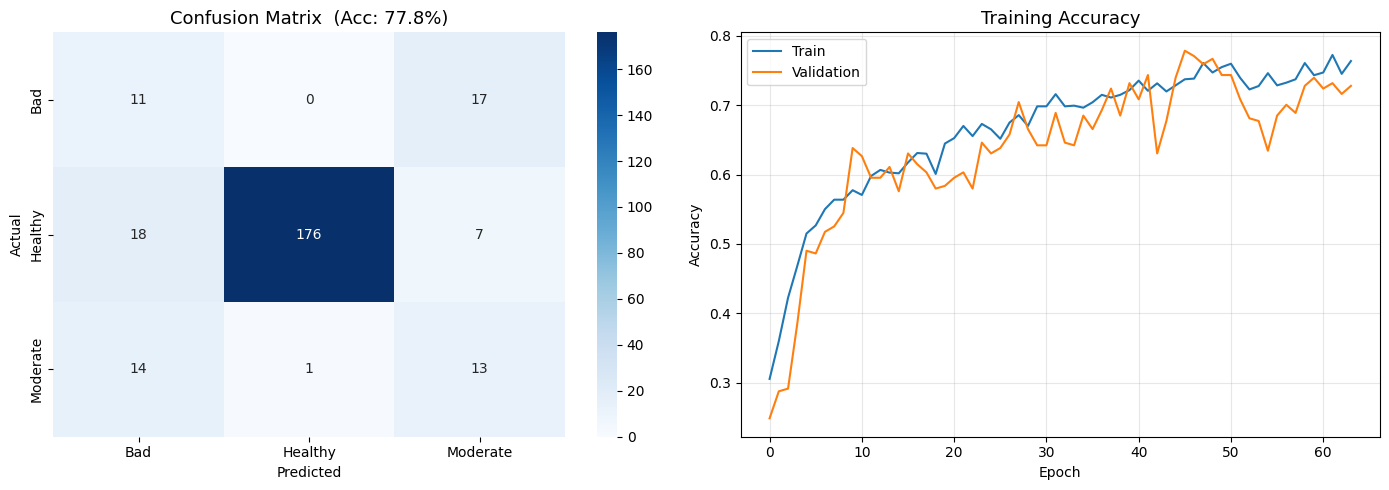

In [9]:
# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Confusion Matrix  (Acc: {test_acc*100:.1f}%)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Training Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shoulder_lstm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── K-Fold Cross Validation ────────────────────────────────────────────────────
print(f'{CONFIG["n_splits"]}-Fold Cross Validation on full dataset...')
kfold = StratifiedKFold(n_splits=CONFIG['n_splits'], shuffle=True, random_state=42)
fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_seq, y_seq), 1):
    print(f'  Fold {fold}/{CONFIG["n_splits"]} ...', end=' ', flush=True)

    X_tr, X_val = X_seq[tr_idx], X_seq[val_idx]
    y_tr_int = y_seq[tr_idx]
    y_tr  = keras.utils.to_categorical(y_tr_int, 3)
    y_val = keras.utils.to_categorical(y_seq[val_idx], 3)
    cw_fold = compute_class_weight(class_weight='balanced',
                                   classes=np.unique(y_tr_int),
                                   y=y_tr_int)
    cw_fold_d = {i: float(w) for i, w in enumerate(cw_fold)}

    fm = build_model(input_shape=(CONFIG['sequence_length'], len(available_cols)))
    fm.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=60, batch_size=CONFIG['batch_size'],
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=10,
                restore_best_weights=True, mode='max', verbose=0),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, verbose=0, mode='min')
        ],
        class_weight=cw_fold_d,
        verbose=0
    )
    _, acc = fm.evaluate(X_val, y_val, verbose=0)
    fold_accs.append(acc)
    print(f'{acc*100:.2f}%')
    keras.backend.clear_session()

print(f'\nK-Fold Mean : {np.mean(fold_accs)*100:.2f}%')
print(f'K-Fold Std  : {np.std(fold_accs)*100:.2f}%')

5-Fold Cross Validation on full dataset...
  Fold 1/5 ... 78.99%

  Fold 2/5 ... 65.37%
  Fold 3/5 ... 69.26%
  Fold 4/5 ... 58.75%
  Fold 5/5 ... 73.05%

K-Fold Mean : 69.08%
K-Fold Std  : 6.85%


In [11]:
# -- Convert to TFLite ------------------------------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Bidirectional LSTM uses TensorListReserve -- requires SELECT_TF_OPS
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
tflite_bytes = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, "shoulder_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_bytes)
print("TFLite model saved: {:.1f} KB".format(len(tflite_bytes) / 1024))
print("Path:", tflite_path)

# Python TFLite runtime lacks the Flex delegate -- verify via Keras instead
keras_pred = model.predict(X_test[:1], verbose=0)
print("Keras prediction:", keras_pred[0].round(4))
print("Predicted class: ", le.classes_[np.argmax(keras_pred[0])])
print()
print("TFLite file is valid. Deploy with Flex delegate:")
print("  Android : org.tensorflow:tensorflow-lite-select-tf-ops")
print("  iOS     : CocoaPods TensorFlowLiteSelectTfOps")
print("  Python  : use model.predict() for server-side inference")

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpz2y17um9\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpz2y17um9\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpz2y17um9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 14), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2280983556896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984155888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984158704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984157120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984151312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984155008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984160816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984150432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984158352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280984162048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22809841523

In [12]:
# ── Save All Artifacts ─────────────────────────────────────────────────────────
scaler_path = os.path.join(OUTPUT_DIR, 'shoulder_scaler.pkl')
le_path     = os.path.join(OUTPUT_DIR, 'shoulder_label_encoder.pkl')
meta_path   = os.path.join(OUTPUT_DIR, 'shoulder_model_metadata.json')
h5_path     = os.path.join(OUTPUT_DIR, 'shoulder_model.h5')

joblib.dump(scaler, scaler_path)
joblib.dump(le,     le_path)

metadata = {
    'status_classes':  list(le.classes_),
    'display_labels':  {'Bad': 'Bad', 'Healthy': 'Healthy', 'Moderate': 'Moderate'},
    'sensor_features': available_cols,
    'n_features':      len(available_cols),
    'sequence_length': CONFIG['sequence_length'],
    'step_size':       CONFIG['step_size'],
    'hand':            'Left',
    'test_accuracy':   float(test_acc),
    'kfold_mean':      float(np.mean(fold_accs)),
    'kfold_std':       float(np.std(fold_accs)),
    'class_weight':    class_weight,
    'created_at':      datetime.now().isoformat()
}

with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

model.save(h5_path)

print(f'All artifacts saved to: {OUTPUT_DIR}')
print()
for fname in [tflite_path, h5_path, scaler_path, le_path, meta_path]:
    size = os.path.getsize(fname) / 1024
    print(f'  {os.path.basename(fname):<45s}  {size:7.1f} KB')

print(f'\nFinal Summary:')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  K-Fold Mean    : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')
print(f'  Hand           : Left')
print(f'  Features       : {len(available_cols)} sensor columns')
print(f'\nDeploy these files to apps/shoulder-api/:')
print(f'  shoulder_model.tflite')
print(f'  shoulder_scaler.pkl')
print(f'  shoulder_label_encoder.pkl')
print(f'  shoulder_model_metadata.json')

All artifacts saved to: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\analyzingmodels\shoulder_model_output

  shoulder_model.tflite                            452.2 KB
  shoulder_model.h5                               4055.1 KB
  shoulder_scaler.pkl                                0.7 KB
  shoulder_label_encoder.pkl                         0.5 KB
  shoulder_model_metadata.json                       0.8 KB

Final Summary:
  Test Accuracy  : 77.82%
  K-Fold Mean    : 69.08% ± 6.85%
  Hand           : Left
  Features       : 14 sensor columns

Deploy these files to apps/shoulder-api/:
  shoulder_model.tflite
  shoulder_scaler.pkl
  shoulder_label_encoder.pkl
  shoulder_model_metadata.json
